---
title: "Maximum Likelihood Estimation"
date: "2026-08-22"
categories:
  - statistics
  - probability
  - machine-learning
---


## Introduction

**Maximum likelihood estimation (MLE)** is a way to estimate unknown parameters from observed data. Given a probabilistic model and observations $x_1, \ldots, x_n$, MLE chooses the parameter value under which those observations are most plausible.

The recipe is simple: write the joint density of the data as a function of the parameter, then maximize it. This note develops the recipe for a deliberately instructive model, $X_i \stackrel{\text{iid}}{\sim} \text{Uniform}(0, \theta)$. The example shows why the support of a distribution matters, why an MLE can occur at a boundary rather than at a stationary point, and why maximum likelihood does not guarantee an unbiased estimator.


### The model

Let

$$
X_1, \ldots, X_n \stackrel{\text{iid}}{\sim} \text{Uniform}(0, \theta),
\qquad \theta > 0,
$$

where $\theta$ is unknown. The density is

$$
f(x; \theta) =
\begin{cases}
1/\theta, & 0 \leq x \leq \theta, \\
0, & \text{otherwise}.
\end{cases}
$$

The population mean and variance are $\mathbb{E}[X] = \theta/2$ and $\operatorname{Var}(X) = \theta^2/12$. More importantly for MLE, the support depends on $\theta$. If the observed sample has maximum

$$
x_{(n)} = \max(x_1, \ldots, x_n),
$$

then every admissible value of $\theta$ must satisfy $\theta \geq x_{(n)}$. A candidate below the sample maximum assigns zero density to an observed value.


### A synthetic sample

Draw 50 observations from $\text{Uniform}(0, 5)$ and keep the true upper bound hidden from the estimation step:


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
theta_true = 5.0
n = 50
data = rng.uniform(0, theta_true, size=n)
x_max = data.max()

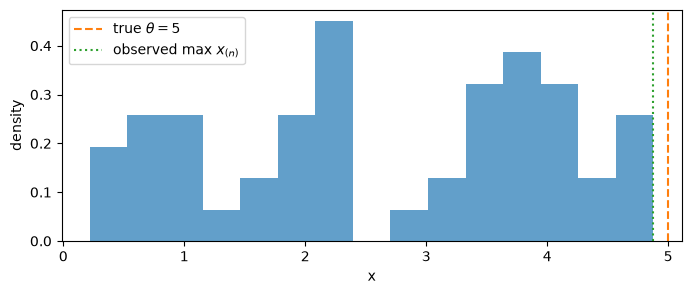

n = 50, true theta = 5.0
sample mean = 2.6762
sample max  = 4.8781


In [2]:
#| code-fold: true
#| label: fig-histogram
#| fig-cap: "**Synthetic sample.** Fifty draws from Uniform(0, 5). The dashed line marks the true upper bound, while the dotted line marks the observed maximum."

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(data, bins=15, density=True, alpha=0.7, color="C0")
ax.axvline(theta_true, color="C1", linestyle="--", label=r"true $\theta = 5$")
ax.axvline(x_max, color="C2", linestyle=":", label=r"observed max $x_{(n)}$")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.legend()
plt.show()

print(f"n = {n}, true theta = {theta_true:.1f}")
print(f"sample mean = {data.mean():.4f}")
print(f"sample max  = {x_max:.4f}")


The observed maximum falls short of the true upper bound, which is typical for a finite sample. The missing interval $(x_{(n)}, \theta]$ contains no observations, but it still belongs to the data-generating distribution. The likelihood will decide how much of that unobserved interval to retain.


### The likelihood

For a fixed observed sample $\boldsymbol{x} = (x_1, \ldots, x_n)$, the **likelihood** treats the data as fixed and the parameter as variable:

$$
L(\theta; \boldsymbol{x})
= \prod_{i=1}^n f(x_i; \theta)
= \theta^{-n}\,
\mathbb{1}\!\left[\theta \geq x_{(n)}\right].
$$

The indicator records the support constraint. For every admissible $\theta \geq x_{(n)}$,

$$
\ell(\theta; \boldsymbol{x})
= \log L(\theta; \boldsymbol{x})
= -n \log \theta.
$$

Maximizing the likelihood or the log-likelihood gives the same answer because the logarithm is strictly increasing. The log form is usually easier to work with because products become sums.


Evaluate the log-likelihood over a grid of candidate upper bounds. The vertical lines show the true parameter and the point where the likelihood first becomes nonzero:


In [3]:
theta_grid = np.linspace(0.5, 6.5, 600)
log_likelihood = np.where(
    theta_grid >= x_max,
    -n * np.log(theta_grid),
    -np.inf,
)

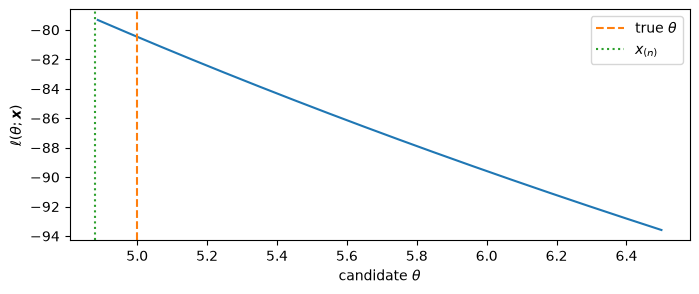

likelihood is zero for theta < 4.8781
analytic maximizer = 4.8781


In [4]:
#| code-fold: true
#| label: fig-likelihood
#| fig-cap: '**Likelihood shape.** The log-likelihood is $-\infty$ below the sample maximum and decreases thereafter, so its maximum occurs at the smallest admissible parameter.'
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(theta_grid, log_likelihood, color="C0")
ax.axvline(theta_true, color="C1", linestyle="--", label=r"true $\theta$")
ax.axvline(x_max, color="C2", linestyle=":", label=r"$x_{(n)}$")
ax.set_xlabel(r"candidate $\theta$")
ax.set_ylabel(r"$\ell(\theta; \boldsymbol{x})$")
ax.legend()
plt.show()

print(f"likelihood is zero for theta < {x_max:.4f}")
print(f"analytic maximizer = {x_max:.4f}")


### Deriving the MLE

The likelihood is zero whenever $\theta < x_{(n)}$. On the admissible region,

$$
\ell(\theta; \boldsymbol{x}) = -n\log\theta,
\qquad
\frac{\mathrm{d}}{\mathrm{d}\theta}\ell(\theta; \boldsymbol{x})
= -\frac{n}{\theta} < 0.
$$

Thus the log-likelihood is strictly decreasing over every admissible value. Its maximum is attained at the smallest admissible value:

$$
\boxed{\widehat{\theta}_{\mathrm{MLE}} = x_{(n)} = \max_i x_i}.
$$

There is no interior critical point to solve for. This is a useful warning: differentiating the log-likelihood is effective for many regular models, but it does not replace checking the parameter space and its boundaries.


### Finite-sample behavior

The MLE is feasible, but it is not unbiased. The distribution of the sample maximum follows directly from independence. For $0 \leq t \leq \theta$,

$$
\Pr(X_{(n)} \leq t)
= \Pr(X_1 \leq t, \ldots, X_n \leq t)
= \left(\frac{t}{\theta}\right)^n.
$$

Equivalently, $X_{(n)}/\theta \sim \operatorname{Beta}(n, 1)$, so

$$
\mathbb{E}[X_{(n)}] = \frac{n}{n+1}\theta,
\qquad
\operatorname{Bias}(\widehat{\theta}_{\mathrm{MLE}})
= -\frac{\theta}{n+1}.
$$

The bias disappears as $n$ grows, which makes the MLE **consistent**. If unbiasedness is important, the sampling distribution suggests the corrected estimator

$$
\widehat{\theta}_{\mathrm{corr}}
= \frac{n+1}{n} X_{(n)},
\qquad
\mathbb{E}[\widehat{\theta}_{\mathrm{corr}}] = \theta.
$$

Bias correction does not make the corrected estimator an MLE. It is a different estimator constructed using the finite-sample behavior of the MLE.

The following simulation compares the raw MLE with the bias-corrected estimator across repeated samples. The corrected estimator should average close to the true value, while the raw MLE should approach it from below:


In [5]:
sample_sizes = np.array([2, 5, 10, 25, 50, 100])
n_reps = 10_000
sim_rng = np.random.default_rng(7)

mle_means = []
corrected_means = []

for sample_size in sample_sizes:  # <1>
    samples = sim_rng.uniform(  # <2>
        0, theta_true, size=(n_reps, sample_size)
    )
    maxima = samples.max(axis=1)  # <3>
    mle_means.append(maxima.mean())  # <4>
    corrected_means.append(  # <5>
        ((sample_size + 1) / sample_size * maxima).mean()
    )


1. Repeat the experiment for each sample size so the finite-sample trend is visible.
2. Draw independent samples from the true $\text{Uniform}(0, \theta)$ distribution.
3. Reduce each repeated sample to its maximum, the MLE for this model.
4. Average the raw MLEs to estimate their expected value.
5. Apply the exact finite-sample correction before averaging the corrected estimates.


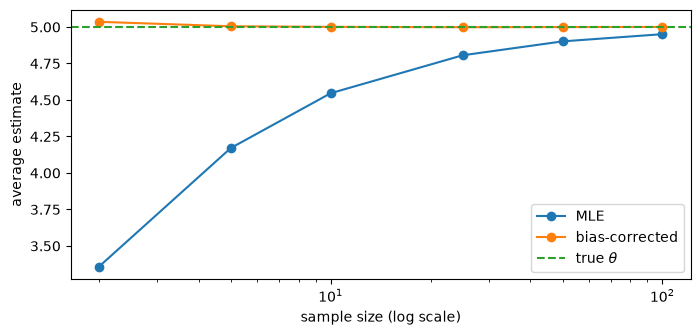

In [6]:
#| label: fig-simulation
#| code-fold: true
#| fig-cap: "**Finite-sample behavior.** Repeated-sample averages show the downward bias of the MLE and the effect of the exact bias correction."

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sample_sizes, mle_means, "o-", label="MLE")
ax.plot(sample_sizes, corrected_means, "o-", label="bias-corrected")
ax.axhline(theta_true, color="C2", linestyle="--", label=r"true $\theta$")
ax.set_xscale("log")
ax.set_xlabel("sample size (log scale)")
ax.set_ylabel("average estimate")
ax.legend()
plt.show()


In [7]:
#| code-fold: true
from IPython.display import Markdown, display

table = [
    "| n | average MLE | theoretical MLE | average corrected |",
    "|---:|---:|---:|---:|",
]

for sample_size, mle_mean, corrected_mean in zip(
    sample_sizes, mle_means, corrected_means
):
    theoretical = sample_size / (sample_size + 1) * theta_true
    table.append(
        f"| {sample_size} | {mle_mean:.4f} | "
        f"{theoretical:.4f} | {corrected_mean:.4f} |"
    )

display(Markdown("\n".join(table)))

| n | average MLE | theoretical MLE | average corrected |
|---:|---:|---:|---:|
| 2 | 3.3571 | 3.3333 | 5.0357 |
| 5 | 4.1709 | 4.1667 | 5.0050 |
| 10 | 4.5463 | 4.5455 | 5.0009 |
| 25 | 4.8063 | 4.8077 | 4.9986 |
| 50 | 4.9015 | 4.9020 | 4.9995 |
| 100 | 4.9510 | 4.9505 | 5.0005 |

The simulation matches the exact calculation:

| Estimator | Expression | Finite-sample behavior |
|---|---|---|
| MLE | $X_{(n)}$ | Feasible, downward biased, consistent |
| Bias-corrected | $\frac{n+1}{n}X_{(n)}$ | Unbiased, consistent, can overshoot $\theta$ |

:::{.callout-note}
This is a **nonregular** MLE problem because the support changes with $\theta$. In regular models, such as a normal model with fixed support, the MLE is often found by setting the score (the derivative of the log-likelihood) to zero. Here the score is always negative on the admissible region, and the answer comes from the boundary.
:::


## Takeaways

Maximum likelihood turns a probabilistic model into an estimation procedure:

1. Write the joint density as a function of the unknown parameter.
2. Identify the parameter values allowed by the support of the observations.
3. Maximize the likelihood, usually through its log.
4. Check the result for bias, consistency, and other finite-sample properties.

For the uniform upper-bound model, the support constraint forces $\theta \geq \max_i x_i$, while the likelihood decreases as $\theta$ increases. The maximum therefore occurs at the sample maximum:

$$
\boxed{\widehat{\theta}_{\mathrm{MLE}} = \max_i x_i}.
$$

The same logic applies to more complicated models. The main difference is that the final maximization may require algebra, numerical optimization, or a specialized algorithm.
